In [1]:
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [2]:
from utils_pourRL import *



pygame 2.6.1 (SDL 2.28.4, Python 3.13.14)
Hello from the pygame community. https://www.pygame.org/contribute.html
[<utils_pourRL.pique object at 0x0000020DC12138C0>, <utils_pourRL.pique object at 0x0000020DC1232710>, <utils_pourRL.carre object at 0x0000020DC1213A10>, <utils_pourRL.pique object at 0x0000020DC120FE10>, <utils_pourRL.carre object at 0x0000020DC1232990>, <utils_pourRL.pique object at 0x0000020DC1876580>, <utils_pourRL.pique object at 0x0000020DB9393850>, <utils_pourRL.pique object at 0x0000020DC180E7B0>, <utils_pourRL.carre object at 0x0000020DC1C18180>, <utils_pourRL.pique object at 0x0000020DB9377930>, <utils_pourRL.pique object at 0x0000020DC18ED8B0>, <utils_pourRL.carre object at 0x0000020DC18767A0>, <utils_pourRL.pique object at 0x0000020DC0A73290>, <utils_pourRL.plateforme object at 0x0000020DC1213B60>, <utils_pourRL.pique object at 0x0000020DC18E0AA0>, <utils_pourRL.pique object at 0x0000020DC1C0E0D0>, <utils_pourRL.pique object at 0x0000020DAFBD92D0>, <utils_pourRL

In [4]:
import importlib
import utils_pourRL

importlib.reload(utils_pourRL)

Affichage = utils_pourRL.Affichage


[<utils_pourRL.pique object at 0x0000022907E23770>, <utils_pourRL.pique object at 0x0000022907E3E5D0>, <utils_pourRL.carre object at 0x0000022907E23CB0>, <utils_pourRL.pique object at 0x00000228FE7B4510>, <utils_pourRL.carre object at 0x0000022907E3EAD0>, <utils_pourRL.pique object at 0x0000022908493020>, <utils_pourRL.pique object at 0x0000022908801050>, <utils_pourRL.pique object at 0x0000022908422B70>, <utils_pourRL.carre object at 0x00000229088242B0>, <utils_pourRL.pique object at 0x000002290020D390>, <utils_pourRL.pique object at 0x00000229084F69C0>, <utils_pourRL.carre object at 0x0000022908493240>, <utils_pourRL.pique object at 0x000002290767F350>, <utils_pourRL.plateforme object at 0x0000022907E23E00>, <utils_pourRL.pique object at 0x00000229002EF280>, <utils_pourRL.pique object at 0x0000022908823750>, <utils_pourRL.pique object at 0x00000229084A3C50>, <utils_pourRL.pique object at 0x0000022900214520>, <utils_pourRL.plateforme object at 0x0000022907E3EE90>, <utils_pourRL.pique 

In [4]:
class DQN(nn.Module):

    def __init__(self, n_observation = 9):
        super().__init__()
        self.layer1 = nn.Linear(n_observation, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [5]:
policy_net = DQN()
target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())

<All keys matched successfully>

In [7]:
def choisir_action(state, epsilon):
    if random.random() < epsilon:
        return random.choice([0,1])
    state = torch.tensor(state, dtype = torch.float32)
    q_values = policy_net(state)
    return torch.argmax(q_values).item()



In [13]:
import time
import pygame
import utils_pourRL

def jouer(jeu):
    state = jeu.reset()
    affichage = utils_pourRL.Affichage(jeu)
    running = True

    policy_net.eval()

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not running:
            break

        state_tensor = torch.tensor(state, dtype=torch.float32)

        with torch.no_grad():
            q_values = policy_net(state_tensor)
            action = torch.argmax(q_values).item()

        next_state, reward, done = jeu.step(action)

        affichage.dessiner()
        pygame.display.flip()

        if done:
            print("Fin de la partie. Score :", jeu.score)
            running = False
        else:
            state = next_state

        time.sleep(1 / 60)

    pygame.quit()

jouer(jeu)

 

Fin de la partie. Score : 220


In [10]:
nb_episodes = 10000
criterion = nn.SmoothL1Loss()
memory = deque(maxlen=20000)
optimizer = optim.Adam(policy_net.parameters(), lr = 0.0005)
step_count = 0
score = []
epsilon = 0.8


for episode in range(nb_episodes):

    state = jeu.reset()
    done = False
    
    
    while not done:
        step_count += 1
        action = choisir_action(state, epsilon)

        next_state, reward, done = jeu.step(action)

        memory.append(
            (state, action, reward, next_state, done)
        )

        if len(memory) >= 64:
            batch = random.sample(memory, 64)
            states, actions, rewards, next_states, dones = zip(*batch)
            states = torch.tensor(states, dtype=torch.float32)
            actions = torch.tensor(actions, dtype=torch.long)
            rewards = torch.tensor(rewards, dtype=torch.float32)
            next_states = torch.tensor(next_states, dtype=torch.float32)
            dones = torch.tensor(dones, dtype=torch.float32)

            output = policy_net(states)
            q_sa = output.gather(1, actions.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                next_q_values = target_net(next_states)
                max_next_q = next_q_values.max(dim=1).values
                cible = rewards + 0.99 * (1 - dones) * max_next_q
            loss = criterion(cible, q_sa)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if step_count % 5000 == 0:
            target_net.load_state_dict(policy_net.state_dict())
            if epsilon > 0:
                epsilon -= 0.07

        state = next_state

    score.append(jeu.score)
    print(loss)



tensor(2.2740, grad_fn=<SmoothL1LossBackward0>)
tensor(2.0089, grad_fn=<SmoothL1LossBackward0>)
tensor(1.9459, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0566, grad_fn=<SmoothL1LossBackward0>)
tensor(2.0078, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0036, grad_fn=<SmoothL1LossBackward0>)
tensor(0.8960, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0928, grad_fn=<SmoothL1LossBackward0>)
tensor(1.9186, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0287, grad_fn=<SmoothL1LossBackward0>)
tensor(0.0363, grad_fn=<SmoothL1LossBackward0>)
tensor(1.7684, grad_fn=<SmoothL1LossBackward0>)
tensor(3.6455, grad_fn=<SmoothL1LossBackward0>)
tensor(1.9582, grad_fn=<SmoothL1LossBackward0>)
tensor(0.4871, grad_fn=<SmoothL1LossBackward0>)
tensor(0.1772, grad_fn=<SmoothL1LossBackward0>)
tensor(1.8872, grad_fn=<SmoothL1LossBackward0>)
tensor(0.2717, grad_fn=<SmoothL1LossBackward0>)
tensor(3.1253, grad_fn=<SmoothL1LossBackward0>)
tensor(1.8624, grad_fn=<SmoothL1LossBackward0>)
tensor(0.1729, grad_fn=<SmoothL1LossBack

KeyboardInterrupt: 

In [11]:
epsilon

-0.04000000000000026

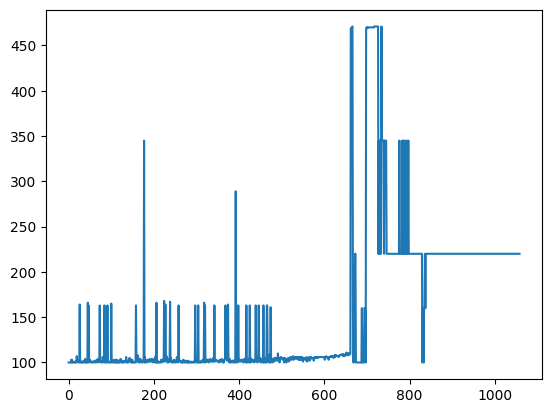

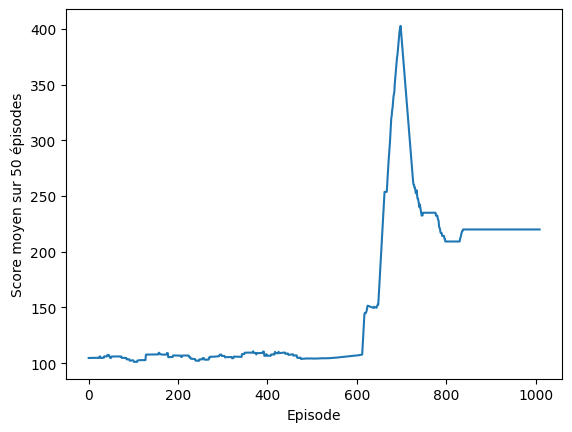

In [12]:
import numpy as np

plt.plot(score)
plt.show()

window = 50

moyennes = np.convolve(
    score,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(moyennes)
plt.xlabel("Episode")
plt.ylabel("Score moyen sur 50 épisodes")
plt.show()